# Support de démonstration — Introduction à Gymnasium

Ce notebook accompagne le chapitre **Introduction à la librairie Gymnasium**.  
Il sert de support de démonstration pour une séance avec des élèves ingénieurs.

## Objectifs
À la fin de cette démonstration, vous saurez :
- installer et importer Gymnasium ;
- créer un environnement ;
- comprendre le cycle `make → reset → step → render → close` ;
- manipuler `action_space` et `observation_space` ;
- distinguer `terminated` et `truncated` ;
- utiliser `info` et `seed` ;
- découvrir quelques wrappers utiles ;
- préparer la transition vers la création d’environnements personnalisés.


## 1. Préparation

> Si Gymnasium n'est pas installé dans votre environnement, exécutez la cellule suivante.


In [2]:
# Installation minimale
# Décommentez si nécessaire :
!pip install gymnasium

# Extras utiles pour plusieurs environnements classiques
!pip install "gymnasium[classic-control]"

print("Décommentez les lignes d'installation si nécessaire.")

   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/952.1 kB ? eta -:--:--
   --------------------------------- ------ 786.4/952.1 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 952.1/952.1 kB 1.8 MB/s  0:00:00

   ------------- -------------------------- 1/3 [cloudpickle]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   -------------------------- ------------- 2/3 [gymnasium]
   ----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Décommentez les lignes d'installation si nécessaire.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import gymnasium as gym
import numpy as np

print("Version de Gymnasium :", gym.__version__)

Version de Gymnasium : 1.2.3


## 2. Qu'est-ce qu'un environnement Gymnasium ?

Un environnement représente un **monde simulé** dans lequel un agent peut agir.

Quelques exemples :
- équilibrer une barre (`CartPole-v1`) ;
- naviguer dans une grille (`FrozenLake-v1`) ;
- contrôler un véhicule simplifié ;
- simuler un problème de décision séquentielle.

L'idée centrale est toujours la même :

**agent → action → environnement → observation + récompense + informations**


## 3. Premier contact avec un environnement

Nous allons commencer avec `CartPole-v1`, un environnement classique de contrôle.


In [4]:
env = gym.make("CartPole-v1")
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>

In [5]:
print("Type de l'environnement :", type(env))
print("Action space :", env.action_space)
print("Observation space :", env.observation_space)
print("Metadata :", env.metadata)
print("Spec :", env.spec)

Type de l'environnement : <class 'gymnasium.wrappers.common.TimeLimit'>
Action space : Discrete(2)
Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Metadata : {'render_modes': ['human', 'rgb_array'], 'render_fps': 50}
Spec : EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')


### À observer
- `action_space` décrit les actions autorisées ;
- `observation_space` décrit la forme des observations ;
- `spec` contient des informations utiles sur l’environnement ;
- l’environnement créé via `make()` est souvent déjà **encapsulé par des wrappers**.


## 4. Le cycle `make → reset → step → close`

Avant toute interaction, il faut appeler `reset()`.


In [6]:
obs, info = env.reset(seed=42)

print("Observation initiale :", obs)
print("Type observation :", type(obs))
print("Info initial :", info)

Observation initiale : [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Type observation : <class 'numpy.ndarray'>
Info initial : {}


### Interprétation
- `obs` : observation initiale ;
- `info` : dictionnaire d’informations auxiliaires ;
- `seed=42` : permet de contrôler l’aléa pour la reproductibilité.


In [7]:
action = env.action_space.sample()
print("Action tirée aléatoirement :", action)

next_obs, reward, terminated, truncated, info = env.step(action)

print("Nouvelle observation :", next_obs)
print("Reward :", reward)
print("Terminated :", terminated)
print("Truncated :", truncated)
print("Info :", info)

Action tirée aléatoirement : 0
Nouvelle observation : [ 0.02727336 -0.20172954  0.03625453  0.32351476]
Reward : 1.0
Terminated : False
Truncated : False
Info : {}


## 5. Comprendre les sorties de `step(action)`

La méthode `step(action)` retourne :

- `observation` : nouvel état observé ;
- `reward` : signal numérique immédiat ;
- `terminated` : fin logique interne du problème ;
- `truncated` : arrêt externe, souvent causé par une limite de temps ;
- `info` : informations auxiliaires.


## 6. Boucle complète sur un épisode

La structure correcte consiste à répéter `step()` jusqu’à ce que :

```python
terminated or truncated
```

devienne vrai.


In [8]:
env = gym.make("CartPole-v1")

obs, info = env.reset(seed=0)
episode_reward = 0.0
step_count = 0

terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward
    step_count += 1

print("Nombre d'étapes :", step_count)
print("Récompense cumulée :", episode_reward)
print("Cause d'arrêt :", "terminated" if terminated else "truncated")

env.close()

Nombre d'étapes : 24
Récompense cumulée : 24.0
Cause d'arrêt : terminated


## 7. Boucle multi-épisodes

On peut maintenant gérer plusieurs épisodes avec une boucle externe.


In [9]:
env = gym.make("CartPole-v1")

results = []

for episode in range(3):
    obs, info = env.reset(seed=episode)
    terminated = False
    truncated = False
    total_reward = 0.0
    steps = 0

    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    results.append({
        "episode": episode,
        "steps": steps,
        "total_reward": total_reward,
        "stop_reason": "terminated" if terminated else "truncated"
    })

env.close()
results

[{'episode': 0,
  'steps': 34,
  'total_reward': 34.0,
  'stop_reason': 'terminated'},
 {'episode': 1,
  'steps': 29,
  'total_reward': 29.0,
  'stop_reason': 'terminated'},
 {'episode': 2,
  'steps': 16,
  'total_reward': 16.0,
  'stop_reason': 'terminated'}]

## 8. Les `spaces`

Les spaces décrivent ce qui est **valide en entrée** et **en sortie**.

Les plus courants :
- `Discrete(n)` : une action parmi `n` choix ;
- `Box(low, high, shape)` : vecteur ou tenseur numérique ;
- `Dict({...})` : observation structurée ;
- `MultiDiscrete([...])` : plusieurs composantes discrètes.


In [10]:
print("Action space :", env.action_space)
print("Observation space :", env.observation_space)

sample_action = env.action_space.sample()
print("Exemple d'action valide :", sample_action)

Action space : Discrete(2)
Observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Exemple d'action valide : 1


In [11]:
from gymnasium.spaces import Discrete, Box, Dict, MultiDiscrete

example_action_space = Discrete(4)
example_obs_space = Dict({
    "agent": Box(0, 4, shape=(2,), dtype=int),
    "target": Box(0, 4, shape=(2,), dtype=int),
})

example_multi = MultiDiscrete([3, 2, 5])

print("Discrete :", example_action_space)
print("Dict :", example_obs_space)
print("MultiDiscrete :", example_multi)

Discrete : Discrete(4)
Dict : Dict('agent': Box(0, 4, (2,), int32), 'target': Box(0, 4, (2,), int32))
MultiDiscrete : MultiDiscrete([3 2 5])


## 9. `seed` et reproductibilité

Deux idées à distinguer :
- `env.reset(seed=...)` contrôle l’aléa de l’environnement ;
- `env.action_space.seed(...)` contrôle l’échantillonnage des actions aléatoires.


In [12]:
env = gym.make("CartPole-v1")

obs1, info1 = env.reset(seed=123)
env.action_space.seed(123)
a1 = env.action_space.sample()

obs2, info2 = env.reset(seed=123)
env.action_space.seed(123)
a2 = env.action_space.sample()

print("Observations initiales égales :", np.allclose(obs1, obs2))
print("Actions échantillonnées égales :", a1 == a2)

env.close()

Observations initiales égales : True
Actions échantillonnées égales : True


## 10. Le rôle de `info`

Le dictionnaire `info` sert à retourner des détails supplémentaires :
- statistiques ;
- événements internes ;
- diagnostics ;
- informations utiles au débogage.


In [13]:
env = gym.make("FrozenLake-v1")

obs, info = env.reset(seed=1)
print("Info après reset :", info)

action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("Info après step :", info)

env.close()

Info après reset : {'prob': 1}
Info après step : {'prob': 0.33333333333333337}


## 11. `terminated` vs `truncated`

Cette distinction est importante :

- `terminated` : la logique du problème dit que l’épisode est fini ;
- `truncated` : l’épisode s’arrête pour une contrainte externe.

L’ancien booléen `done` était moins explicite.


In [14]:
env = gym.make("CartPole-v1", max_episode_steps=10)

obs, info = env.reset(seed=0)

for t in range(20):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"t={t:02d} | terminated={terminated} | truncated={truncated}")
    if terminated or truncated:
        print("Episode arrêté.")
        break

env.close()

t=00 | terminated=False | truncated=False
t=01 | terminated=False | truncated=False
t=02 | terminated=False | truncated=False
t=03 | terminated=False | truncated=False
t=04 | terminated=False | truncated=False
t=05 | terminated=False | truncated=False
t=06 | terminated=False | truncated=False
t=07 | terminated=False | truncated=False
t=08 | terminated=False | truncated=False
t=09 | terminated=False | truncated=True
Episode arrêté.


## 12. Rendu visuel avec `render()`

Le comportement de `render()` dépend du `render_mode` choisi à la création.


In [15]:
# Cette cellule retourne une image en mémoire
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset(seed=0)

frame = env.render()
print("Type du rendu :", type(frame))
print("Shape :", frame.shape if hasattr(frame, "shape") else "N/A")

env.close()

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Type du rendu : <class 'numpy.ndarray'>
Shape : (400, 600, 3)


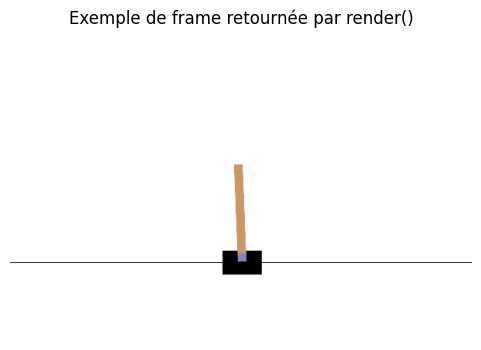

In [16]:
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset(seed=0)
frame = env.render()

plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("Exemple de frame retournée par render()")
plt.show()

env.close()

### Modes fréquents
- `human` : affichage à l’écran ;
- `rgb_array` : image en mémoire ;
- `ansi` : rendu texte pour certains environnements.


In [17]:
env = gym.make("FrozenLake-v1", render_mode="ansi")
obs, info = env.reset(seed=0)

print(env.render())

env.close()


SFFF
FHFH
FFFH
HFFG



## 13. Les wrappers

Un wrapper permet de **modifier ou enrichir** un environnement sans réécrire son code source.

Exemples fréquents :
- `TimeLimit`
- `OrderEnforcing`
- `PassiveEnvChecker`
- `RecordEpisodeStatistics`
- `RecordVideo`


In [18]:
env = gym.make("CartPole-v1")
print(env)
env.close()

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>


En affichant l’environnement, on voit souvent une chaîne de wrappers déjà appliqués par défaut.


## 14. Wrapper utile : `RecordEpisodeStatistics`


In [19]:
from gymnasium.wrappers import RecordEpisodeStatistics

env = gym.make("CartPole-v1")
env = RecordEpisodeStatistics(env)

obs, info = env.reset(seed=0)
terminated = False
truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

print("Contenu de info en fin d'épisode :", info.get("episode"))

env.close()

Contenu de info en fin d'épisode : {'r': 21.0, 'l': 21, 't': 0.003261}


## 15. Wrapper utile : `RecordVideo`

Cette cellule est fournie comme exemple.  
Elle peut nécessiter un environnement local compatible avec l’écriture de vidéos.


In [ ]:
# Exemple d'utilisation de RecordVideo
# Décommentez si vous voulez tester localement.

# from gymnasium.wrappers import RecordVideo
# env = gym.make("CartPole-v1", render_mode="rgb_array")
# env = RecordVideo(env, video_folder="videos")

# obs, info = env.reset(seed=0)
# terminated = truncated = False
# while not (terminated or truncated):
#     action = env.action_space.sample()
#     obs, reward, terminated, truncated, info = env.step(action)

# env.close()

print("Exemple prêt à être activé localement.")

## 16. Mini démonstration structurée

Voici un squelette propre que vous pouvez réutiliser en TP ou en cours.


In [20]:
def run_random_policy(env_id: str, episodes: int = 3, seed: int = 0):
    env = gym.make(env_id)
    summaries = []

    for ep in range(episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = False
        truncated = False
        total_reward = 0.0
        steps = 0

        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        summaries.append({
            "episode": ep,
            "steps": steps,
            "total_reward": total_reward,
            "stop_reason": "terminated" if terminated else "truncated"
        })

    env.close()
    return summaries

run_random_policy("CartPole-v1", episodes=5, seed=10)

[{'episode': 0,
  'steps': 23,
  'total_reward': 23.0,
  'stop_reason': 'terminated'},
 {'episode': 1,
  'steps': 28,
  'total_reward': 28.0,
  'stop_reason': 'terminated'},
 {'episode': 2,
  'steps': 22,
  'total_reward': 22.0,
  'stop_reason': 'terminated'},
 {'episode': 3,
  'steps': 17,
  'total_reward': 17.0,
  'stop_reason': 'terminated'},
 {'episode': 4,
  'steps': 37,
  'total_reward': 37.0,
  'stop_reason': 'terminated'}]

## 17. Exercices rapides à faire en séance

### Exercice 1
Remplacer `CartPole-v1` par `FrozenLake-v1` et comparer :
- l’espace d’action ;
- l’observation ;
- la récompense.

### Exercice 2
Afficher à chaque pas :
- l’action choisie ;
- la récompense ;
- l’état de `terminated` et `truncated`.

### Exercice 3
Accumuler la récompense totale sur 10 épisodes et calculer la moyenne.

### Exercice 4
Tester différents `render_mode` quand ils sont disponibles.


## 18. Ouverture vers un environnement personnalisé

Avant de créer un environnement personnalisé, il faut bien maîtriser :
- la logique `reset()` / `step()` ;
- les spaces ;
- la gestion de `info` ;
- les conditions `terminated` / `truncated` ;
- le rendu et la fermeture propre avec `close()`.


In [ ]:
# Exemple de structure minimale d'un environnement personnalisé (squelette non exécutable complet)

custom_env_skeleton = '''
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class MyEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, render_mode=None):
        super().__init__()
        self.render_mode = render_mode
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=4, shape=(2,), dtype=np.int32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs = np.array([0, 0], dtype=np.int32)
        info = {}
        return obs, info

    def step(self, action):
        obs = np.array([0, 0], dtype=np.int32)
        reward = 0.0
        terminated = False
        truncated = False
        info = {}
        return obs, reward, terminated, truncated, info

    def render(self):
        pass

    def close(self):
        pass
'''
print(custom_env_skeleton)

## 19. Synthèse

### À retenir
- Gymnasium standardise l’interaction avec des environnements simulés ;
- le cycle fondamental est `make → reset → step → render → close` ;
- `step()` retourne 5 éléments ;
- `terminated` et `truncated` ont des rôles distincts ;
- les spaces structurent les entrées et sorties ;
- `seed` améliore la reproductibilité ;
- les wrappers enrichissent l’environnement sans le réécrire.

Ce notebook peut servir de base directe pour une démonstration en classe ou un TP d’introduction.
